In [1]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True
DATA_PATH = r"kod\data\processed\mereni.parquet"
TEMP_PATH = r"kod\data\processed\mereni.tmp.parquet"

# Načtení dat

In [2]:
df = pl.read_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema)
if PRINT: describe(df, True)

CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vozidlo_Vin,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Vozidlo_CisloMotoru,Vozidlo_Odometer,Vozidlo_RokVyroby,Vozidlo_DatumPrvniRegistrace,Vozidlo_Palivo,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotka,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_TesnostPlynovehoZarizeni,Vysledek_Vyhovuje,PristiProhlidka,EmisniSystem,Obd_KomunikacniProtokol,Obd_Vin,Obd_PocetDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_KontrolaMil,Obd_VypisDtc,Zavady,Obd_Readiness_Vysledek,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_J1939_AC_Podporovano,Obd_Readiness_J1939_AC_Otestovano,Obd_Readiness_J1939_BOOST_Podporovano,Obd_Readiness_J1939_BOOST_Otestovano,Obd_Readiness_J1939_CAT-FUNC_Podporovano,Obd_Readiness_J1939_CAT-FUNC_Otestovano,Obd_Readiness_J1939_COLD_Podporovano,Obd_Readiness_J1939_COLD_Otestovano,Obd_Readiness_J1939_COMP_Podporovano,Obd_Readiness_J1939_COMP_Otestovano,Obd_Readiness_J1939_DPF_Podporovano,Obd_Readiness_J1939_DPF_Otestovano,Obd_Readiness_J1939_EGR-VVT_Podporovano,Obd_Readiness_J1939_EGR-VVT_Otestovano,Obd_Readiness_J1939_EGS-FUNC_Podporovano,Obd_Readiness_J1939_EGS-FUNC_Otestovano,Obd_Readiness_J1939_EGS-HEAT_Podporovano,Obd_Readiness_J1939_EGS-HEAT_Otestovano,Obd_Readiness_J1939_EVAP_Podporovano,Obd_Readiness_J1939_EVAP_Otestovano,Obd_Readiness_J1939_FUEL_Podporovano,Obd_Readiness_J1939_FUEL_Otestovano,Obd_Readiness_J1939_HCAT_Podporovano,Obd_Readiness_J1939_HCAT_Otestovano,Obd_Readiness_J1939_MISF_Podporovano,Obd_Readiness_J1939_MISF_Otestovano,Obd_Readiness_J1939_NM-HC_Podporovano,Obd_Readiness_J1939_NM-HC_Otestovano,Obd_Readiness_J1939_NOX_Podporovano,Obd_Readiness_J1939_NOX_Otestovano,Obd_Readiness_J1939_SAS_Podporovano,Obd_Readiness_J1939_SAS_Otestovano,Benzin_Palivo,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_Otacky

(20537568, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-420930-19-01-0001,2019-01-01,420930,2019-01-01T14:43:55.0200000+01:00,2019-01-01T15:06:04.3900000+01:00,47287,CZ-420930-19-01-0001,2019-01-01T14:51:00,ActiaCZ,AT605,...,None,None,None,None,None,None,None,None,None,None
1,CZ-520406-19-01-0001,2019-01-01,520406,2019-01-01T15:22:33.2900000+01:00,2019-01-01T15:39:51.5500000+01:00,16835,CZ-520406-19-01-0001,2019-01-01T15:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,None,None,None,None,None,None,None,None,None,None
2,CZ-170901-23-01-0002,2023-01-01,170901,2023-01-01T19:42:08.8770000+01:00,2023-01-01T19:53:03.3100000+01:00,89493,CZ-170901-23-01-0002,2023-01-01T19:50:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
3,CZ-480811-23-01-0001,2023-01-01,480811,2023-01-01T12:22:13.5700000+01:00,2023-01-01T12:36:18.7000000+01:00,36479,CZ-480811-23-01-0001,2023-01-01T12:33:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
4,CZ-420221-23-01-0001,2023-01-01,420221,2023-01-01T16:07:06.1270000+01:00,2023-01-01T16:17:16.0300000+01:00,44365,CZ-420221-23-01-0001,2023-01-01T16:17:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
5,CZ-420221-23-01-0003,2023-01-01,420221,2023-01-01T16:57:28.1900000+01:00,2023-01-01T17:06:11.8300000+01:00,44365,CZ-420221-23-01-0003,2023-01-01T17:05:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
6,CZ-170901-23-01-0001,2023-01-01,170901,2023-01-01T19:24:30.3070000+01:00,2023-01-01T19:36:25.5270000+01:00,89493,CZ-170901-23-01-0001,2023-01-01T19:32:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None
7,CZ-420221-23-01-0004,2023-01-01,420221,2023-01-01T17:26:23.7170000+01:00,2023-01-01T17:41:10.1600000+01:00,44365,CZ-420221-23-01-0004,2023-01-01T17:40:00,ACTIA CZ s.r.o.,AT605,...,None,None,None,None,None,None,None,None,None,None
8,CZ-520406-24-01-0001,2024-01-01,520406,2024-01-01T11:31:17.2900000+01:00,2024-01-01T11:48:07.5200000+01:00,1308,CZ-520406-24-01-0001,2024-01-01T11:38:00,AVL DiTEST GmbH,AVL Gas 1000,...,None,None,None,None,None,None,None,None,None,None
9,CZ-480811-24-01-0001,2024-01-01,480811,2024-01-01T16:22:23.1070000+01:00,2024-01-01T16:36:09.9300000+01:00,36479,CZ-480811-24-01-0001,2024-01-01T16:31:00,MAHLE,OPA-100,...,None,None,None,None,None,None,None,None,None,None


# Přetypování sloupců

In [3]:
df = cast_mereni(df)

# Vyber mereni, ktera maji protejsek v prohlidkach (zajisteni stejnych filtru)

In [4]:
lf_prohlidky = pl.scan_parquet(r'kod\data\extracted\prohlidky_vozidel_stk_a_sme\parquet', schema=prohlidky_schema)
id_prohlidky_series = lf_prohlidky.select('CisloProtokolu').unique().collect(engine='streaming').get_column('CisloProtokolu')

if PRINT:
    id_prohlidky = set(id_prohlidky_series)
    id_mereni = set(df.get_column('CisloProtokolu'))
    orphan = list(id_prohlidky - id_mereni)
    display(lf_prohlidky.filter(pl.col('CisloProtokolu').is_in(orphan)).collect(engine='streaming')['DatumProhlidky'].value_counts(sort=True))

df = df.join(id_prohlidky_series.to_frame("CisloProtokolu"), on="CisloProtokolu", how="semi")

DatumProhlidky,count
str,u32
"""2026-02-27""",9459
"""2023-11-02""",2
"""2024-02-15""",2
"""2024-11-15""",2
"""2024-11-20""",2
…,…
"""2022-07-26""",1
"""2023-07-28""",1
"""2022-11-29""",1


# Odstraneni nekterych sloupcu
### Rok_vyroby

In [5]:
if PRINT: print(f'Podil mereni, ktera maji rok vyroby mensi nez 1000: {len(df.filter(pl.col('Vozidlo_RokVyroby') < 1000)) / df.height * 100:.2f} %')

Podil mereni, ktera maji rok vyroby mensi nez 1000: 25.41 %


### Vysledek_RidiciJednotka

In [6]:
if PRINT: 
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 1)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 2)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])
    print(df.select('Vysledek_RidiciJednotkaStav', 'Vysledek_RidiciJednotka').filter(pl.col('Vysledek_RidiciJednotkaStav') == 3)['Vysledek_RidiciJednotka'].value_counts(sort=True)['Vysledek_RidiciJednotka'].to_list()[:10])

['---', 'bez závad', '', None, 'Celkem 0 závad ', 'Bez závad', 'BEZ ZÁVAD', 'OK', 'ok', 'Nebyly zjištěny závady']
['---', None, '', 'BEZ ZÁVAD', 'bez závad', 'OK', 'registrované DTC nejsou emisně relevantní', 'Bez závad', 'BEZ ZAVAD', 'VYHOVUJE']
['---', None, 'emisně relevantní závady', '', 'Bez závad', 'Celkem 1 závada P0380', 'Celkem Chybová hlášení v paměti. závad ', 'Celkem 1 závada P0420', 'Celkem 1 závada P0401', 'Celkem 1 závada P0670']


### Obd_VypisDTC

In [7]:
if PRINT: 
    obd_vypis_dtc_non_null = df['Obd_VypisDtc'].filter(df['Obd_VypisDtc'].is_not_null())
    print(f'Podil, kdy obd vypis dtc neni null: {len(obd_vypis_dtc_non_null) / df.height * 100:.2f} %')
    print(obd_vypis_dtc_non_null.to_list()[:10])

Podil, kdy obd vypis dtc neni null: 3.19 %
[['P0263'], ['P2279'], ['P0401', 'P0113'], ['P1351', 'P0401', 'P0409', 'P1162', 'P0490'], ['P0046'], ['4364'], ['P0238', 'P2126', 'P0409', 'P1351', 'P1162', 'P0490'], ['P0420'], ['P2BAE', 'P2BAE', 'U041B', 'P2202', 'P2206', 'P2209', 'U1009'], ['P0403']]


### J1939
- Odstraneni radku, ktere hodnoty obsahuji

In [8]:
j1939_df = df.filter(
    pl.any_horizontal(
        pl.col("^.*J1939.*$").is_not_null()
    )
)
if PRINT: short_display(j1939_df)
# Modifikace df
df = df.join(j1939_df, on="CisloProtokolu", how="anti")

(122937, 321)


,CisloProtokolu,DatumProhlidky,StaniceCislo,Zahajeni,Ukonceni,OdpovednaOsoba,Prohlidka_CisloProtokolu,Prohlidka_DatumProhlidky,MericiPristroj_Vyrobce,MericiPristroj_Typ,...,Plyn_OtackyZvysene_NOX_Hodnota,Plyn_OtackyZvysene_NOX_Vysledek,Plyn_OtackyZvysene_O2_Hodnota,Plyn_OtackyZvysene_O2_Vysledek,Plyn_OtackyZvysene_TPS_Hodnota,Plyn_OtackyZvysene_TPS_Vysledek,Plyn_Nadrz_Vyrobce,Plyn_Nadrz_Homologace,Plyn_Nadrz_Zivotnost,Plyn_Nadrz_Kontrola
0,CZ-471025-19-02-0020,2019-02-01,471025,2019-02-01 15:46:41.467,2019-02-01 16:03:17.410,37829,CZ-471025-19-02-0020,2019-02-01 15:54:00,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,CZ-470326-19-02-0005,2019-02-01,470326,2019-02-01 18:41:28.243,2019-02-01 19:10:59.900,37965,CZ-470326-19-02-0005,2019-02-01 19:10:00,ActiaCZ,AT605,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,CZ-570316-19-02-0002,2019-02-01,570316,2019-02-01 19:42:01.057,2019-02-01 20:13:22.723,36507,CZ-570316-19-02-0002,2019-02-01 21:06:00,MAHA,MDO-2,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,CZ-420620-19-02-0040,2019-02-01,420620,2019-02-01 15:45:44.650,2019-02-01 15:51:37.700,47163,CZ-420620-19-02-0040,2019-02-01 15:47:00,Bosch,RTM430,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,CZ-560613-19-02-0020,2019-02-01,560613,2019-02-01 15:04:08.253,2019-02-01 15:12:10.327,21187,CZ-560613-19-02-0020,2019-02-01 15:04:10,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
5,CZ-540514-19-02-0121,2019-02-01,540514,2019-02-01 14:24:43.517,2019-02-01 14:32:21.287,34793,CZ-540514-19-02-0121,2019-02-01 14:27:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
6,CZ-540514-19-02-0123,2019-02-01,540514,2019-02-01 15:04:36.370,2019-02-01 15:13:38.030,34793,CZ-540514-19-02-0123,2019-02-01 15:08:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
7,CZ-530104-19-02-0035,2019-02-01,530104,2019-02-01 14:21:13.143,2019-02-01 14:29:20.410,40997,CZ-530104-19-02-0035,2019-02-01 14:24:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
8,CZ-540514-19-02-0111,2019-02-01,540514,2019-02-01 13:39:46.033,2019-02-01 13:47:25.997,6807,CZ-540514-19-02-0111,2019-02-01 13:37:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
9,CZ-530104-19-02-0029,2019-02-01,530104,2019-02-01 13:31:43.277,2019-02-01 13:43:21.083,49407,CZ-530104-19-02-0029,2019-02-01 13:37:00,AVL DiTEST GmbH,AVL DiSmoke 480,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None


### Plyn_PocetVyusteni

In [9]:
if PRINT: display(df['Plyn_PocetVyusteni'].value_counts())

Plyn_PocetVyusteni,count
i8,u32
2,1581
1,526927
0,19886120


### PristiProhlidka

In [10]:
if PRINT: display(df.filter(pl.col('PristiProhlidka').is_not_null())['Vysledek_Vyhovuje'].value_counts())

Vysledek_Vyhovuje,count
bool,u32
true,19871582


In [11]:
duplicate_cols = ['DatumProhlidky', 'Zahajeni', 'Ukonceni', 'OdpovednaOsoba', 'Prohlidka_DatumProhlidky', 'Vozidlo_Vin', 'Vozidlo_Znacka', 'Vozidlo_ObchodniOznaceni', 'Vozidlo_TypMotoru', 'Vozidlo_CisloMotoru', 'Vozidlo_Odometer', 'Vozidlo_DatumPrvniRegistrace', 'Vozidlo_Palivo', 'Obd_Vin']
irrelevant_cols = ['Prohlidka_CisloProtokolu', 'Vozidlo_RokVyroby', 'Vysledek_RidiciJednotka', 'Vysledek_TesnostPlynovehoZarizeni', 'PristiProhlidka', 'Benzin_Palivo', 'Nafta_Palivo']
j1939_cols = ['Obd_Readiness_J1939_AC_Podporovano', 'Obd_Readiness_J1939_AC_Otestovano', 'Obd_Readiness_J1939_BOOST_Podporovano', 'Obd_Readiness_J1939_BOOST_Otestovano', 'Obd_Readiness_J1939_CAT-FUNC_Podporovano', 'Obd_Readiness_J1939_CAT-FUNC_Otestovano', 'Obd_Readiness_J1939_COLD_Podporovano', 'Obd_Readiness_J1939_COLD_Otestovano', 'Obd_Readiness_J1939_COMP_Podporovano', 'Obd_Readiness_J1939_COMP_Otestovano', 'Obd_Readiness_J1939_DPF_Podporovano', 'Obd_Readiness_J1939_DPF_Otestovano', 'Obd_Readiness_J1939_EGR-VVT_Podporovano', 'Obd_Readiness_J1939_EGR-VVT_Otestovano', 'Obd_Readiness_J1939_EGS-FUNC_Podporovano', 'Obd_Readiness_J1939_EGS-FUNC_Otestovano', 'Obd_Readiness_J1939_EGS-HEAT_Podporovano', 'Obd_Readiness_J1939_EGS-HEAT_Otestovano', 'Obd_Readiness_J1939_EVAP_Podporovano', 'Obd_Readiness_J1939_EVAP_Otestovano', 'Obd_Readiness_J1939_FUEL_Podporovano', 'Obd_Readiness_J1939_FUEL_Otestovano', 'Obd_Readiness_J1939_HCAT_Podporovano', 'Obd_Readiness_J1939_HCAT_Otestovano', 'Obd_Readiness_J1939_MISF_Podporovano', 'Obd_Readiness_J1939_MISF_Otestovano', 'Obd_Readiness_J1939_NM-HC_Podporovano', 'Obd_Readiness_J1939_NM-HC_Otestovano', 'Obd_Readiness_J1939_NOX_Podporovano', 'Obd_Readiness_J1939_NOX_Otestovano', 'Obd_Readiness_J1939_SAS_Podporovano', 'Obd_Readiness_J1939_SAS_Otestovano']
plyn_cols = ['Plyn_Palivo', 'Plyn_PocetVyusteni', 'Plyn_OtackyVolnobezne_CO_Max_Hodnota', 'Plyn_OtackyVolnobezne_CO_Max_RucniZadani', 'Plyn_OtackyVolnobezne_CO_Hodnota', 'Plyn_OtackyVolnobezne_CO_Vysledek', 'Plyn_OtackyVolnobezne_CO2_Hodnota', 'Plyn_OtackyVolnobezne_CO2_Vysledek', 'Plyn_OtackyVolnobezne_COCOOR_Hodnota', 'Plyn_OtackyVolnobezne_COCOOR_Vysledek', 'Plyn_OtackyVolnobezne_HC_Max_Hodnota', 'Plyn_OtackyVolnobezne_HC_Max_RucniZadani', 'Plyn_OtackyVolnobezne_HC_Hodnota', 'Plyn_OtackyVolnobezne_HC_Vysledek', 'Plyn_OtackyVolnobezne_LAMBDA_Min_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Min_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Max_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Max_RucniZadani', 'Plyn_OtackyVolnobezne_LAMBDA_Hodnota', 'Plyn_OtackyVolnobezne_LAMBDA_Vysledek', 'Plyn_OtackyVolnobezne_N_Min_Hodnota', 'Plyn_OtackyVolnobezne_N_Min_RucniZadani', 'Plyn_OtackyVolnobezne_N_Max_Hodnota', 'Plyn_OtackyVolnobezne_N_Max_RucniZadani', 'Plyn_OtackyVolnobezne_N_Hodnota', 'Plyn_OtackyVolnobezne_N_Vysledek', 'Plyn_OtackyVolnobezne_NOX_Hodnota', 'Plyn_OtackyVolnobezne_NOX_Vysledek', 'Plyn_OtackyVolnobezne_O2_Hodnota', 'Plyn_OtackyVolnobezne_O2_Vysledek', 'Plyn_OtackyVolnobezne_TPS_Hodnota', 'Plyn_OtackyVolnobezne_TPS_Vysledek', 'Plyn_OtackyZvysene_CO_Max_Hodnota', 'Plyn_OtackyZvysene_CO_Max_RucniZadani', 'Plyn_OtackyZvysene_CO_Hodnota', 'Plyn_OtackyZvysene_CO_Vysledek', 'Plyn_OtackyZvysene_CO2_Hodnota', 'Plyn_OtackyZvysene_CO2_Vysledek', 'Plyn_OtackyZvysene_COCOOR_Hodnota', 'Plyn_OtackyZvysene_COCOOR_Vysledek', 'Plyn_OtackyZvysene_HC_Max_Hodnota', 'Plyn_OtackyZvysene_HC_Max_RucniZadani', 'Plyn_OtackyZvysene_HC_Hodnota', 'Plyn_OtackyZvysene_HC_Vysledek', 'Plyn_OtackyZvysene_LAMBDA_Min_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Min_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Max_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Max_RucniZadani', 'Plyn_OtackyZvysene_LAMBDA_Hodnota', 'Plyn_OtackyZvysene_LAMBDA_Vysledek', 'Plyn_OtackyZvysene_N_Min_Hodnota', 'Plyn_OtackyZvysene_N_Min_RucniZadani', 'Plyn_OtackyZvysene_N_Max_Hodnota', 'Plyn_OtackyZvysene_N_Max_RucniZadani', 'Plyn_OtackyZvysene_N_Hodnota', 'Plyn_OtackyZvysene_N_Vysledek', 'Plyn_OtackyZvysene_NOX_Hodnota', 'Plyn_OtackyZvysene_NOX_Vysledek', 'Plyn_OtackyZvysene_O2_Hodnota', 'Plyn_OtackyZvysene_O2_Vysledek', 'Plyn_OtackyZvysene_TPS_Hodnota', 'Plyn_OtackyZvysene_TPS_Vysledek', 'Plyn_Nadrz_Vyrobce', 'Plyn_Nadrz_Homologace', 'Plyn_Nadrz_Zivotnost', 'Plyn_Nadrz_Kontrola']
df = df.drop(duplicate_cols + irrelevant_cols + j1939_cols + plyn_cols)

# Unikatnost cisla protokolu
- nasledne odstraneno stanice cislo

In [12]:
if PRINT: print(f'Délka datasetu před odstraněním duplicitních řádků: {df.height}')

df = df.unique()
if PRINT: print(f'Délka datasetu po odstranění duplicitních řádků: {df.height}')

non_unique = df.select(pl.col('CisloProtokolu')).filter(pl.col('CisloProtokolu').is_duplicated())['CisloProtokolu'].unique().to_list()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').is_in(non_unique)).sort(by=['CisloProtokolu', 'StaniceCislo']))

df = df.filter(~pl.col('CisloProtokolu').is_in(non_unique) | (pl.col('CisloProtokolu').str.split('-').list.get(1).cast(pl.Int32) == pl.col("StaniceCislo")))
if PRINT: print(f'Délka datasetu po odstranění vsech duplicitnich cisel protokolu: {df.height}')
df = df.drop('StaniceCislo')

Délka datasetu před odstraněním duplicitních řádků: 20414628
Délka datasetu po odstranění duplicitních řádků: 20413791
(8, 202)


,CisloProtokolu,StaniceCislo,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Poznamky,Vysledek_VisualniKontrola,Vysledek_Readiness,...,Nafta_Mereni3_CasAkcelerace_Hodnota,Nafta_Mereni3_CasAkcelerace_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek
0,CZ-540308-24-02-0512,3420,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CZ-540308-24-02-0512,540308,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS540,1.0,1,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CZ-540308-24-02-0561,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CZ-540308-24-02-0561,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,None,1.0,1,True,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CZ-540308-24-02-0563,3420,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CZ-540308-24-02-0563,540308,Bosch,BEA050,BEA V2.02 3AA30592 / AMM 000-B6 F54B /,KTS540,1.0,1,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CZ-550309-23-06-0452,3521,MAHLE,OPA-100,-,None,2021.0.1,4,True,None,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0
7,CZ-550309-23-06-0452,550309,MAHLE,OPA-100,-,None,2021.0.1,4,True,None,...,1.18,1.0,0.51,1.0,2130.0,1.0,600.0,1.0,80.0,1.0


Délka datasetu po odstranění vsech duplicitnich cisel protokolu: 20413787


# Serazeni sloupcu podle textu prace

In [13]:
df = df.select([
    # Identifikace měření
    "CisloProtokolu",

    # Měřicí přístroj
    "MericiPristroj_Vyrobce",
    "MericiPristroj_Typ",
    "MericiPristroj_Verze",
    "MericiPristroj_OBD",
    "MericiPristroj_VerzeSoftware",

    # Výsledek měření
    "Vysledek_VisualniKontrola",
    "Vysledek_Readiness",
    "Vysledek_RidiciJednotkaStav",
    "Vysledek_Mil",
    "Vysledek_Vyhovuje",
    "Obd_Readiness_Vysledek",
    "Zavady",
    "Poznamky",

    # Emisní systém (rizenyOBD)
    "EmisniSystem",
    "Obd_KomunikacniProtokol",
    "Obd_KontrolaMil",
    "Obd_PocetDtc",
    "Obd_VypisDtc",
    "Obd_VzdalenostDtc",
    "Obd_CasDtc",
    *sorted([c for c in df.columns if "Obd_Readiness_Zazeh" in c]),
    *sorted([c for c in df.columns if "Obd_Readiness_Vznet" in c]),

    # Detail měření dle typu paliva - Benzin
    "Benzin_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyVolnobezne")]),
    *sorted([c for c in df.columns if c.startswith("Benzin_OtackyZvysene")]),

    # Detail měření dle typu paliva - Nafta
    "Nafta_PocetVyusteni",
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniVznetLimit")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_MereniPrumer")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni0")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni1")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni2")]),
    *sorted([c for c in df.columns if c.startswith("Nafta_Mereni3")])
])

# Chybejici hodnoty

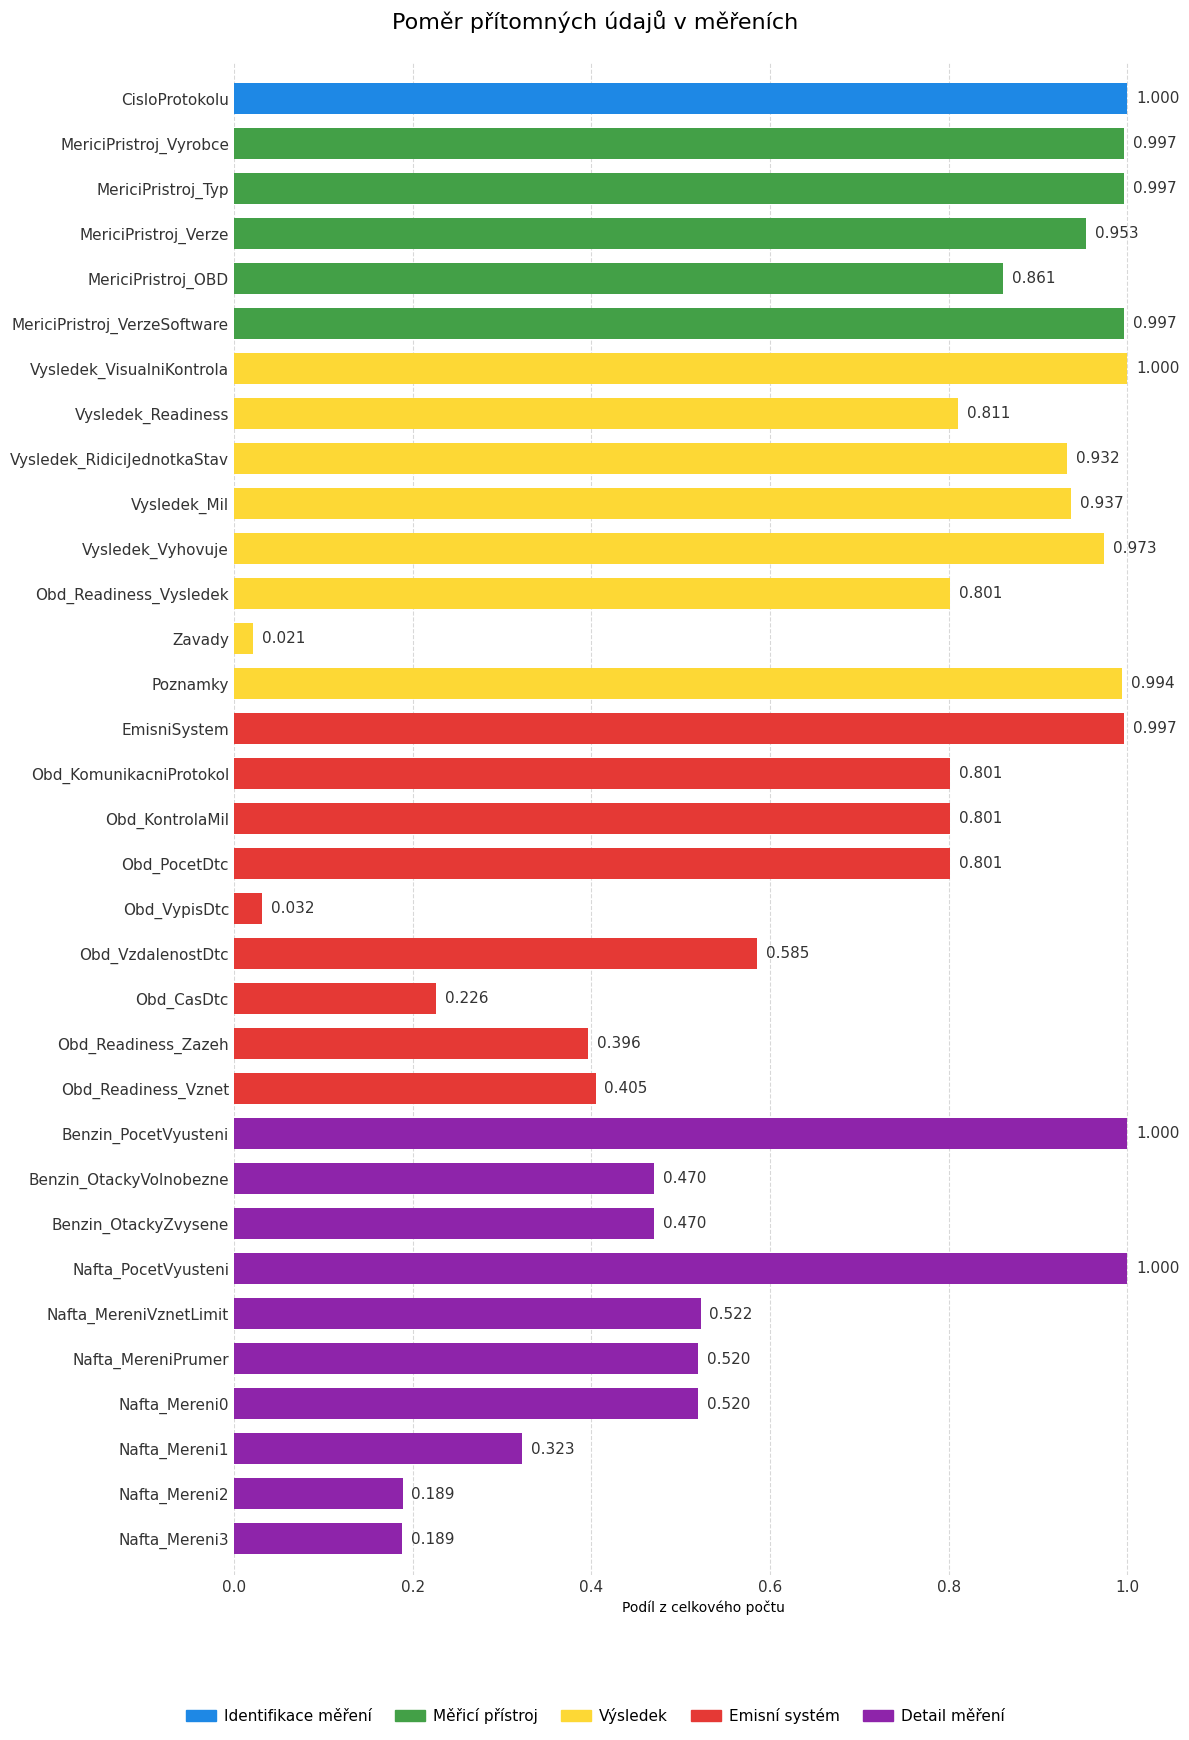

In [14]:
if PRINT: 
    # Definice agregačních skupin
    aggregation_groups = {
        'Obd_Readiness_Zazeh': [c for c in df.columns if 'Obd_Readiness_Zazeh' in c],
        'Obd_Readiness_Vznet': [c for c in df.columns if 'Obd_Readiness_Vznet' in c],
        'Benzin_OtackyVolnobezne': [c for c in df.columns if c.startswith('Benzin_OtackyVolnobezne_')],
        'Benzin_OtackyZvysene': [c for c in df.columns if c.startswith('Benzin_OtackyZvysene_')],
        'Nafta_MereniVznetLimit': [c for c in df.columns if c.startswith('Nafta_MereniVznetLimit_')],
        'Nafta_MereniPrumer': [c for c in df.columns if c.startswith('Nafta_MereniPrumer_')],
        'Nafta_Mereni0': [c for c in df.columns if c.startswith('Nafta_Mereni0_')],
        'Nafta_Mereni1': [c for c in df.columns if c.startswith('Nafta_Mereni1_')],
        'Nafta_Mereni2': [c for c in df.columns if c.startswith('Nafta_Mereni2_')],
        'Nafta_Mereni3': [c for c in df.columns if c.startswith('Nafta_Mereni3_')],
    }

    # Inverzní mapování: sloupec -> název skupiny
    col_to_group = {col: g_name for g_name, g_cols in aggregation_groups.items() for col in g_cols}

    # Výpočet metrik se zachováním pořadí z df.columns
    total_rows = len(df)
    final_labels = []
    final_ratios = []
    processed_groups = set()

    for col in df.columns:
        if col in col_to_group:
            group_name = col_to_group[col]
            if group_name not in processed_groups:
                # Výpočet pro celou skupinu (aspoň jedna ne-null hodnota)
                group_cols = aggregation_groups[group_name]
                any_present_count = df.select(
                    pl.any_horizontal(pl.col(group_cols).is_not_null())
                ).sum().item()
                final_labels.append(group_name)
                final_ratios.append(any_present_count / total_rows if total_rows > 0 else 0)
                processed_groups.add(group_name)
        else:
            # Samostatný sloupec
            non_null_count = total_rows - df[col].null_count()
            final_labels.append(col)
            final_ratios.append(non_null_count / total_rows if total_rows > 0 else 0)

    # Kategorizace (6 skupin včetně Vozidla)
    group_descriptions = [
        'Identifikace měření',
        'Měřicí přístroj',
        'Výsledek',  
        'Emisní systém', 
        'Detail měření'  
    ]

    def map_to_main_category(label):
        if label == 'CisloProtokolu': return 0
        if label.startswith('MericiPristroj'): return 1
        if any(x in label for x in ['Vysledek', 'PristiProhlidka', 'Zavady', 'Poznamky']): return 2
        if label.startswith('EmisniSystem') or label.startswith('Obd'): return 3
        if label.startswith('Benzin') or label.startswith('Nafta'): return 4
        return 3

    group_indices = [map_to_main_category(l) for l in final_labels]

    # Generování grafu
    horizontal_bar(
        labels=final_labels, 
        counts=final_ratios, 
        title='Poměr přítomných údajů v měřeních', 
        save_path='kod/explorace/mereni_grafy/mereni_pritomnost.svg', 
        decimals=3, 
        height=18, 
        group_indices=group_indices, 
        group_descriptions=group_descriptions
    )

### Emisni systemy

In [15]:
if PRINT: display(df['EmisniSystem'].value_counts(sort=True).with_columns(pl.col('count') / df.height))

EmisniSystem,count
enum,f64
"""Rizeny_Obd""",0.801281
"""Rizeny""",0.161724
"""Nerizeny""",0.03377
null,0.003225


### Pocet mereni u nafty

In [16]:
if PRINT: 
    print(f'Pomer dieselu, co ma alespon 2 mereni: {0.264 / 0.456 * 100:.2f} %')
    print(f'Pomer dieselu, co ma 3 a 4 mereni: {0.146 / 0.456 * 100:.2f} %')

Pomer dieselu, co ma alespon 2 mereni: 57.89 %
Pomer dieselu, co ma 3 a 4 mereni: 32.02 %


# Ulozeni dat

In [17]:
if PRINT: schema_description(df)
df.write_parquet(r"kod\data\processed\mereni_tmp.parquet")

,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-530104-19-06-0350,1 / 20 413 787,0 / 20 413 787,String
1,MericiPristroj_Vyrobce,Bosch,6 660 207 / 20 413 787,65 825 / 20 413 787,String
2,MericiPristroj_Typ,AT605,2 656 741 / 20 413 787,65 825 / 20 413 787,String
3,MericiPristroj_Verze,-,7 074 699 / 20 413 787,951 462 / 20 413 787,String
4,MericiPristroj_OBD,R+OBD,3 902 492 / 20 413 787,2 846 849 / 20 413 787,String
...,...,...,...,...,...
196,Nafta_Mereni3_OtackyVolnobezne_Vysledek,1,3 849 619 / 20 413 787,16 562 466 / 20 413 787,Int8
197,Nafta_Mereni3_TPS_Hodnota,0.0,2 141 550 / 20 413 787,17 787 543 / 20 413 787,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,2 571 776 / 20 413 787,17 787 543 / 20 413 787,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,754 834 / 20 413 787,17 203 643 / 20 413 787,Float32


In [ ]:
df = pl.read_parquet(r"kod\data\processed\mereni_tmp.parquet")

## Pro dalsi analyzu uvazovany pouze Rizene emisni systemy
- odstraneny i zaznamy, ktere maji skoro same null (pro analyzu vsak mene relevantni - pouze jako vysledek)
- diky tomu neni mereno HC

In [19]:
if PRINT: print(f'Podil rizenych: {df['EmisniSystem'].value_counts().filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))['count'].sum() / df.height * 100:.2f} %')
df_small = df.filter(pl.col('EmisniSystem').cast(pl.String).str.contains('Rizeny'))
# EmisniSystem uz obsahoval pouze 2 hodnoty
df_small = df_small.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

Podil rizenych: 96.30 %


# Odstraneni chybnych zaznamu
## Zaporne hodnoty

In [20]:
if PRINT:
    # Filtrace a výpis vzorku (ponecháno pro logiku výpisu řádků)
    df_negative = df_small.filter(pl.any_horizontal(cs.numeric() < 0))
    print(f'Pocet zaznamu se zapornou hodnou: {df_negative.height}')
    
    for row in df_negative.head(5).iter_rows(named=True):
        negatives = [f"{k}: {v}" for k, v in row.items() if isinstance(v, (int, float)) and v < 0]
        print(f"{row['CisloProtokolu']}: {', '.join(negatives)}")

    # Efektivní agregace počtu záporných hodnot
    negative_counts = (
        df_small.select(
            (cs.numeric() < 0).sum()
        )
        .unpivot(variable_name="sloupec", value_name="pocet_zapornych")
        .filter(pl.col("pocet_zapornych") > 0)
        .sort("pocet_zapornych", descending=True)
    )
    display(negative_counts.to_pandas())

df_small = df_small.filter(pl.any_horizontal(~(cs.numeric() < 0)))

Pocet zaznamu se zapornou hodnou: 7876
CZ-410441-25-03-0029: Benzin_OtackyZvysene_O2_Hodnota: -0.019999999552965164
CZ-570523-20-04-0089: Benzin_OtackyVolnobezne_O2_Hodnota: -0.10000000149011612
CZ-480616-25-03-0185: Benzin_OtackyVolnobezne_O2_Hodnota: -0.009999999776482582, Benzin_OtackyZvysene_O2_Hodnota: -0.009999999776482582
CZ-560703-25-02-0106: Benzin_OtackyVolnobezne_O2_Hodnota: -0.03999999910593033
CZ-410441-24-09-0099: Benzin_OtackyZvysene_O2_Hodnota: -0.009999999776482582


,sloupec,pocet_zapornych
0,Benzin_OtackyZvysene_O2_Hodnota,6428
1,Benzin_OtackyVolnobezne_O2_Hodnota,3716
2,Benzin_OtackyVolnobezne_HC_Hodnota,209
3,Benzin_OtackyVolnobezne_CO_Hodnota,183
4,Benzin_OtackyZvysene_HC_Hodnota,129
5,Benzin_OtackyZvysene_CO_Hodnota,114
6,Benzin_OtackyVolnobezne_COCOOR_Hodnota,1
7,Benzin_OtackyVolnobezne_NOX_Hodnota,1
8,Benzin_OtackyZvysene_COCOOR_Hodnota,1
9,Benzin_OtackyZvysene_NOX_Hodnota,1


## Filtrace zaznamu predstavujicich konkretni mereni pro benzin nebo naftu

In [21]:
required_benzin = [
    # Benzin Vždy (Volnoběžné)
    "Benzin_OtackyVolnobezne_CO_Hodnota",
    "Benzin_OtackyVolnobezne_CO_Max_Hodnota",
    "Benzin_OtackyVolnobezne_N_Hodnota",
    "Benzin_OtackyVolnobezne_N_Min_Hodnota",
    "Benzin_OtackyVolnobezne_N_Max_Hodnota",
    
    # Benzin Zvýšené
    "Benzin_OtackyZvysene_LAMBDA_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota",
    "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota",
    "Benzin_OtackyZvysene_CO_Max_Hodnota",
    "Benzin_OtackyZvysene_N_Hodnota",
    "Benzin_OtackyZvysene_N_Min_Hodnota",
    "Benzin_OtackyZvysene_N_Max_Hodnota"
]

required_nafta = [
    # Nafta Průměr
    "Nafta_MereniPrumer_CasAkcelerace_Hodnota",
    "Nafta_MereniPrumer_Kourivost_Hodnota",
    "Nafta_MereniPrumer_OtackyVolnobezne_Hodnota",
    "Nafta_MereniPrumer_OtackyPrebehove_Hodnota",
    
    # Nafta Limit Max
    "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota",
    "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota",
    
    # Nafta Limit Min
    "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota",
    "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota"
]

benzin_mask = pl.all_horizontal(pl.col(required_benzin).is_not_null())
nafta_mask = pl.all_horizontal(pl.col(required_nafta).is_not_null())
if PRINT:
    # Filtrace na vyhovující měření před analýzou
    mask_ok = pl.col("Vysledek_Vyhovuje").fill_null(False) == True
    df_ok = df_small.filter(mask_ok)
    n_ok = df_ok.height

    # Filtrace neúplných záznamů pouze z vyhovujících
    df_partial = df_ok.filter(~(benzin_mask | nafta_mask))
    
    print(f'Podíl neúplných záznamů (v rámci vyhovujících): {df_partial.height / n_ok * 100:.4f} %')
    print(f'Počet záznamů s benzinem i naftou (v rámci vyhovujících): {df_ok.filter((pl.col("Nafta_PocetVyusteni") > 0) & (pl.col("Benzin_PocetVyusteni") > 0)).height}')

    # Analýza kategorií v rámci vyhovujících
    benzin_all_null = pl.all_horizontal(pl.col(required_benzin).is_null())
    nafta_all_null = pl.all_horizontal(pl.col(required_nafta).is_null())
    
    vse_chybi_count = df_partial.filter(benzin_all_null & nafta_all_null).height
    print(f'\nChybí úplně vše (benzin i nafta) u vyhovujících: {vse_chybi_count / n_ok * 100:.4f} %')

    def display_partial_stats(df, columns, label, n_total):
        # Filtrace na záznamy s aspoň jednou chybějící hodnotou, ale ne všemi
        is_partial = pl.any_horizontal(pl.col(columns).is_null()) & ~pl.all_horizontal(pl.col(columns).is_null())
        df_p = df.filter(is_partial)
        n_group = df_p.height
        
        # Výpis podílu této skupiny vůči všem vyhovujícím
        print(f'\nČástečně chybějící {label} u vyhovujících: {n_group / n_total * 100:.4f} %')
        
        if n_group > 0:
            # Agregace chybějících hodnot převedená na Polars DataFrame pro Data Wrangler
            stats = (
                df_p.select(pl.col(columns).null_count())
                .unpivot(variable_name="sloupec", value_name="chybi_pocet")
                .filter(pl.col("chybi_pocet") > 0)
                .with_columns(
                    podil_v_skupine_pct = (pl.col("chybi_pocet") / n_group * 100).round(2)
                )
                .sort("chybi_pocet", descending=True)
            )
            display(stats)

    # Detailní statistiky pro specifické podskupiny vyhovujících měření
    display_partial_stats(df_partial, required_benzin, "BENZÍN", n_ok)
    display_partial_stats(df_partial, required_nafta, "NAFTA", n_ok)

df_small = df_small.filter(benzin_mask | nafta_mask)

Podíl neúplných záznamů (v rámci vyhovujících): 0.3543 %
Počet záznamů s benzinem i naftou (v rámci vyhovujících): 0

Chybí úplně vše (benzin i nafta) u vyhovujících: 0.3470 %

Částečně chybějící BENZÍN u vyhovujících: 0.0047 %


sloupec,chybi_pocet,podil_v_skupine_pct
str,u32,f64
"""Benzin_OtackyVolnobezne_N_Hodn…",910,100.0
"""Benzin_OtackyVolnobezne_N_Min_…",910,100.0
"""Benzin_OtackyVolnobezne_N_Max_…",910,100.0
"""Benzin_OtackyZvysene_N_Hodnota""",897,98.57
"""Benzin_OtackyZvysene_N_Min_Hod…",897,98.57
…,…,…
"""Benzin_OtackyVolnobezne_CO_Max…",8,0.88
"""Benzin_OtackyZvysene_LAMBDA_Ho…",1,0.11
"""Benzin_OtackyZvysene_LAMBDA_Mi…",1,0.11



Částečně chybějící NAFTA u vyhovujících: 0.0026 %


sloupec,chybi_pocet,podil_v_skupine_pct
str,u32,f64
"""Nafta_MereniPrumer_CasAkcelera…",500,100.0
"""Nafta_MereniPrumer_Kourivost_H…",500,100.0
"""Nafta_MereniPrumer_OtackyVolno…",500,100.0
"""Nafta_MereniPrumer_OtackyPrebe…",500,100.0


## Kontrola limitu
### Benzin

In [22]:
limits_bounds_benzin = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Benzin_OtackyVolnobezne_CO_Max_Hodnota', 0.05, 5.0),
    ('Benzin_OtackyVolnobezne_N_Min_Hodnota', 300, 3000),
    ('Benzin_OtackyVolnobezne_N_Max_Hodnota', 300, 3000),
    ('Benzin_OtackyZvysene_CO_Max_Hodnota', 0.01, 1.0),
    ('Benzin_OtackyZvysene_LAMBDA_Min_Hodnota', 0.9, 1.00),
    ('Benzin_OtackyZvysene_LAMBDA_Max_Hodnota', 1.00, 1.1),
    ('Benzin_OtackyZvysene_N_Min_Hodnota', 1000, 10000),
    ('Benzin_OtackyZvysene_N_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_benzin:
    if PRINT: print(f'Podil hodnot mimo limit pro {limit_bound[0]}: {df_small.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height / df_small.height * 100:.2f} %.')

for limit_bound in limits_bounds_benzin:
    df_small = df_small.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | nafta_mask)

Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_CO_Max_Hodnota: 0.05 %.
Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyVolnobezne_N_Max_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_CO_Max_Hodnota: 0.04 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Min_Hodnota: 0.08 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 0.09 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_N_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Benzin_OtackyZvysene_N_Max_Hodnota: 0.01 %.


### Nafta

In [23]:
limits_bounds_nafta = [
    # (Název atributu limitu, Očekávané MIN limitu, Očekávané MAX limitu)
    ('Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota', 0.1, 10.0),
    ('Nafta_MereniVznetLimit_Kourivost_Max_Hodnota', 0.01, 3.0),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota', 300, 3000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota', 1000, 10000),
    ('Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota', 1000, 10000)
]

for limit_bound in limits_bounds_nafta:
    if PRINT: print(f'Podil hodnot mimo limit pro {limit_bound[0]}: {df_small.filter(~pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2])).height / df_small.height * 100:.2f} %.')

for limit_bound in limits_bounds_nafta:
    df_small = df_small.filter(pl.col(limit_bound[0]).is_between(limit_bound[1], limit_bound[2]) | benzin_mask)

Podil hodnot mimo limit pro Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota: 0.00 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_Kourivost_Max_Hodnota: 1.07 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota: 0.01 %.
Podil hodnot mimo limit pro Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 0.01 %.


### Nesmyslne delky intervalu

In [24]:
# Seznam dvojic limitů pro kontrolu integrity
check_limits_integrity = [
    ("Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

for min_col, max_col in check_limits_integrity:
    if PRINT: print(f'Pocet hodnot se zapornou nebo nulovou delkou intervalu {min_col}, {max_col}: {df_small.filter(pl.col(min_col) >= pl.col(max_col)).height}')
    df_small = df_small.filter((pl.col(min_col).ne(pl.col(max_col))).fill_null(True))

Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyVolnobezne_N_Min_Hodnota, Benzin_OtackyVolnobezne_N_Max_Hodnota: 19
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_LAMBDA_Min_Hodnota, Benzin_OtackyZvysene_LAMBDA_Max_Hodnota: 5
Pocet hodnot se zapornou nebo nulovou delkou intervalu Benzin_OtackyZvysene_N_Min_Hodnota, Benzin_OtackyZvysene_N_Max_Hodnota: 363
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota, Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota: 36
Pocet hodnot se zapornou nebo nulovou delkou intervalu Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota, Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota: 134


## Filtrace pouze uspesnych mereni

In [25]:
if PRINT: print(f'Podil uspesnych: {df_small.filter(pl.col('Vysledek_Vyhovuje') == True).height / df_small.height * 100:.2f} %')
df_small = df_small.filter(pl.col('Vysledek_Vyhovuje') == True).drop('Vysledek_Vyhovuje')

Podil uspesnych: 97.78 %


# Extrakce dulezitych informaci

## Normalizace hodnot

In [26]:
# Definice mapování pro normalizaci
all_mappings = [
    ("Benzin_OtackyVolnobezne_CO_Hodnota", None, "Benzin_OtackyVolnobezne_CO_Max_Hodnota"),
    ("Benzin_OtackyVolnobezne_N_Hodnota", "Benzin_OtackyVolnobezne_N_Min_Hodnota", "Benzin_OtackyVolnobezne_N_Max_Hodnota"),
    ("Benzin_OtackyZvysene_LAMBDA_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Min_Hodnota", "Benzin_OtackyZvysene_LAMBDA_Max_Hodnota"),
    ("Benzin_OtackyZvysene_CO_Hodnota", None, "Benzin_OtackyZvysene_CO_Max_Hodnota"),
    ("Benzin_OtackyZvysene_N_Hodnota", "Benzin_OtackyZvysene_N_Min_Hodnota", "Benzin_OtackyZvysene_N_Max_Hodnota"),
    ("Nafta_MereniPrumer_CasAkcelerace_Hodnota", None, "Nafta_MereniVznetLimit_CasAkcelerace_Max_Hodnota"),
    ("Nafta_MereniPrumer_Kourivost_Hodnota", None, "Nafta_MereniVznetLimit_Kourivost_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyVolnobezne_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyVolnobezne_Max_Hodnota"),
    ("Nafta_MereniPrumer_OtackyPrebehove_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Min_Hodnota", "Nafta_MereniVznetLimit_OtackyPrebehove_Max_Hodnota")
]

exprs = []
for val_col, min_col, max_col in all_mappings:
    low = pl.col(min_col) if min_col else pl.lit(0)
    high = pl.col(max_col)
    val = pl.col(val_col)
    
    # Normalizace
    norm_expr = ((val - low) / (high - low)).alias(f"{val_col}_Norm")
    exprs.append(norm_expr)

df_small = df_small.with_columns(exprs).drop((cs.starts_with('Benzin_') | cs.starts_with('Nafta_')) & (~cs.ends_with('PocetVyusteni')) & (~cs.ends_with('_Norm')))

## Spojeni informaci o mericim pristroji do Vyrobce a Typu

In [27]:
df_small = df_small.with_columns((pl.col('MericiPristroj_Vyrobce') + pl.col('MericiPristroj_Typ')).alias('MericiPristroj_Info')).drop(cs.contains("MericiPristroj") & (~cs.by_name("MericiPristroj_Info")))

## Pro nizkou ruznorodost ponechano pouze Obd_PocetDtc z DTC

In [28]:
df_small = df_small.drop(cs.contains('Dtc') & (~cs.by_name('Obd_PocetDtc')))

## Readiness podpory a otestovani prevedeno do poctu True

In [29]:
df_small = df_small.with_columns(pl.sum_horizontal(cs.ends_with("_Podporovano")).alias("Pocet_Podporovano"), pl.sum_horizontal(cs.ends_with("_Otestovano")).alias("Pocet_Otestovano"))
df_small = df_small.drop((cs.ends_with("_Podporovano") | cs.ends_with("_Otestovano")) & (~cs.by_name("Pocet_Podporovano")) & (~cs.by_name("Pocet_Otestovano")))

## Redukce seznamů na pocet prvku

In [30]:
df_small = df_small.with_columns(pl.col('Poznamky').list.len().fill_null(0), pl.col('Zavady').list.len().fill_null(0))

## Ulozeni mezivypoctu

In [31]:
df_small.write_parquet(r"kod\data\processed\mereni_small.parquet")

# Analyza zpracovaneho datasetu

In [32]:
df_small = pl.read_parquet(r'kod/data/processed/mereni_small.parquet')
df_benzin = df_small.filter(pl.col('Benzin_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Benzin_'))
df_nafta = df_small.filter(pl.col('Nafta_PocetVyusteni') > 0).select(cs.ends_with('_Norm') & cs.starts_with('Nafta_'))

## Rozdeleni a prazdne hodnoty

In [33]:
if PRINT:
    display(df_benzin.describe())
    display(df_nafta.describe())

statistic,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm
str,f64,f64,f64,f64,f64
"""count""",9.214296e6,9.214296e6,9.214296e6,9.214296e6,9.214296e6
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",0.132455,0.512862,0.606585,0.332217,0.465915
"""std""",0.504406,0.227972,11.121516,0.399538,0.303929
"""min""",-0.54,-15.5,-33.000031,-0.2,-40.0
"""25%""",0.0,0.4,0.483334,0.05,0.255
"""50%""",0.04,0.5,0.55,0.2,0.455
"""75%""",0.166667,0.605,0.7,0.58,0.666
"""max""",920.0,144.5,17050.517578,633.333313,100.900002


statistic,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm
str,f64,f64,f64,f64
"""count""",9.640523e6,9.640523e6,9.640523e6,9.640523e6
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.208073,0.285891,0.450764,0.461902
"""std""",0.305539,3.21407,0.358772,0.837408
"""min""",0.0,0.0,-39.5,-103.0
"""25%""",0.0,0.019608,0.329167,0.34
"""50%""",0.2,0.156863,0.496667,0.5
"""75%""",0.315,0.511364,0.55,0.65
"""max""",526.280029,9236.363281,77.0,220.399994


## Hodnoty mimo rozsah

In [34]:
def print_values_invalid(df):
    for col in df.columns:
        print(f'Relativni cetnost pozorovani {col} mimo rozsah <0, 1>: {df.filter(~pl.col(col).is_between(0, 1)).height / df.height * 100:.2f} %')

if PRINT:
    print_values_invalid(df_benzin)
    print_values_invalid(df_nafta)

Relativni cetnost pozorovani Benzin_OtackyVolnobezne_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyVolnobezne_N_Hodnota_Norm mimo rozsah <0, 1>: 1.17 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_CO_Hodnota_Norm mimo rozsah <0, 1>: 0.01 %
Relativni cetnost pozorovani Benzin_OtackyZvysene_N_Hodnota_Norm mimo rozsah <0, 1>: 3.37 %
Relativni cetnost pozorovani Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm mimo rozsah <0, 1>: 0.06 %
Relativni cetnost pozorovani Nafta_MereniPrumer_Kourivost_Hodnota_Norm mimo rozsah <0, 1>: 0.02 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm mimo rozsah <0, 1>: 0.89 %
Relativni cetnost pozorovani Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm mimo rozsah <0, 1>: 2.05 %


### Nekdy je to zpusobeno spatnym zaokrouhlenim, jindy ne

In [35]:
if PRINT:
    df_kourivost_mimo = df_small.filter(~pl.col('Nafta_MereniPrumer_Kourivost_Hodnota_Norm').is_between(0, 1))
    short_display(df_kourivost_mimo)
    example_ids = df_kourivost_mimo['CisloProtokolu'][:10].to_list()
    short_display(pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(pl.col('CisloProtokolu'), pl.col('^.*Kourivost.*$')).filter(pl.col('CisloProtokolu').is_in(example_ids)).collect(engine='streaming'))

(1574, 26)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano
0,CZ-460313-25-03-0462,True,True,1.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.2000,1.117647,0.500000,0.333333,AVL DiTEST GmbHAVL DiSmoke 480,2,11
1,CZ-170901-22-12-0079,True,True,1.0,2.0,True,0,3,True,ISO9141,...,NaN,NaN,NaN,0.2640,1.600000,0.355000,0.925000,MAHLEOPA-100,3,11
2,CZ-480633-22-12-0227,True,True,1.0,2.0,True,0,4,True,ISO 14230,...,NaN,NaN,NaN,0.3220,1.585714,0.350000,0.200000,AVL DiTEST GmbHAVL DiSmoke 480,3,11
3,CZ-450915-21-08-0493,True,True,1.0,2.0,True,0,3,True,CAN (ISO 15765-4),...,NaN,NaN,NaN,0.3220,1.078431,0.530000,0.120000,BoschKTS540,3,9
4,CZ-472201-19-08-0190,True,True,NaN,2.0,None,0,3,False,None,...,NaN,NaN,NaN,0.5640,1.385714,0.280000,0.452500,BoschMTM-BEA,0,0
5,CZ-450915-21-04-0459,True,True,1.0,2.0,True,0,4,True,ISO K-Line,...,NaN,NaN,NaN,0.2640,1.011905,0.550000,0.070000,BoschKTS540,3,8
6,CZ-470509-24-08-0013,True,True,1.0,2.0,True,0,2,True,ISO 9141,...,NaN,NaN,NaN,0.2600,1.600000,0.425000,0.575000,AVL DiTEST GmbHAVL DiSmoke 480,3,11
7,CZ-560307-25-04-0415,True,True,2.0,2.0,True,0,1,True,ISO 15765,...,NaN,NaN,NaN,0.2000,1.080000,0.500000,0.980000,AVL DiTEST GmbHAVL DiSmoke 480,5,11
8,CZ-480301-22-02-0011,True,True,1.0,2.0,True,0,2,True,ISO 15765,...,NaN,NaN,NaN,0.0000,1.920000,0.666667,0.575000,AVL DiTEST GmbHAVL DiSmoke 480,6,11
9,CZ-450402-25-10-0159,True,False,1.0,2.0,True,0,5,True,ISO9141,...,NaN,NaN,NaN,0.2800,1.180000,0.496875,0.727500,MAHLEOPA-100,3,9


(10, 15)


,CisloProtokolu,Nafta_MereniVznetLimit_Kourivost_Max_Hodnota,Nafta_MereniVznetLimit_Kourivost_Max_RucniZadani,Nafta_MereniVznetLimit_KourivostRozpeti_Max_Hodnota,Nafta_MereniVznetLimit_KourivostRozpeti_Max_RucniZadani,Nafta_MereniPrumer_Kourivost_Hodnota,Nafta_MereniPrumer_Kourivost_Vysledek,Nafta_Mereni0_Kourivost_Hodnota,Nafta_Mereni0_Kourivost_Vysledek,Nafta_Mereni1_Kourivost_Hodnota,Nafta_Mereni1_Kourivost_Vysledek,Nafta_Mereni2_Kourivost_Hodnota,Nafta_Mereni2_Kourivost_Vysledek,Nafta_Mereni3_Kourivost_Hodnota,Nafta_Mereni3_Kourivost_Vysledek
0,CZ-470509-24-08-0013,0.90,true,0.25,true,1.44,1,1.47,1,1.43,1,1.39,1,1.48,1
1,CZ-480301-22-02-0011,0.25,true,0.25,false,0.48,1,0.48,1,None,None,None,None,None,None
2,CZ-450402-25-10-0159,1.50,true,0.25,false,1.77,1,1.85,1,1.69,1,None,None,None,None
3,CZ-480633-22-12-0227,0.70,true,0.25,false,1.11,1,1.14,1,1.1,1,1.2,1,0.99,1
4,CZ-170901-22-12-0079,0.80,true,0.25,false,1.28,1,1.22,1,1.33,1,None,None,None,None
5,CZ-560307-25-04-0415,0.250,false,0.250,false,0.27,0,0.27,0,None,None,None,None,None,None
6,CZ-472201-19-08-0190,0.70,false,0.25,false,0.97,1,1.35,1,1.46,1,0.58,1,0.47,1
7,CZ-450915-21-08-0493,0.51,false,0.25,false,0.55,1,0.56,1,0.56,1,0.58,1,0.51,1
8,CZ-460313-25-03-0462,0.510,false,0.250,false,0.57,0,0.68,0,0.46,0,None,None,None,None
9,CZ-450915-21-04-0459,1.68,false,0.25,false,1.7,1,1.74,1,1.68,1,1.69,1,1.68,1


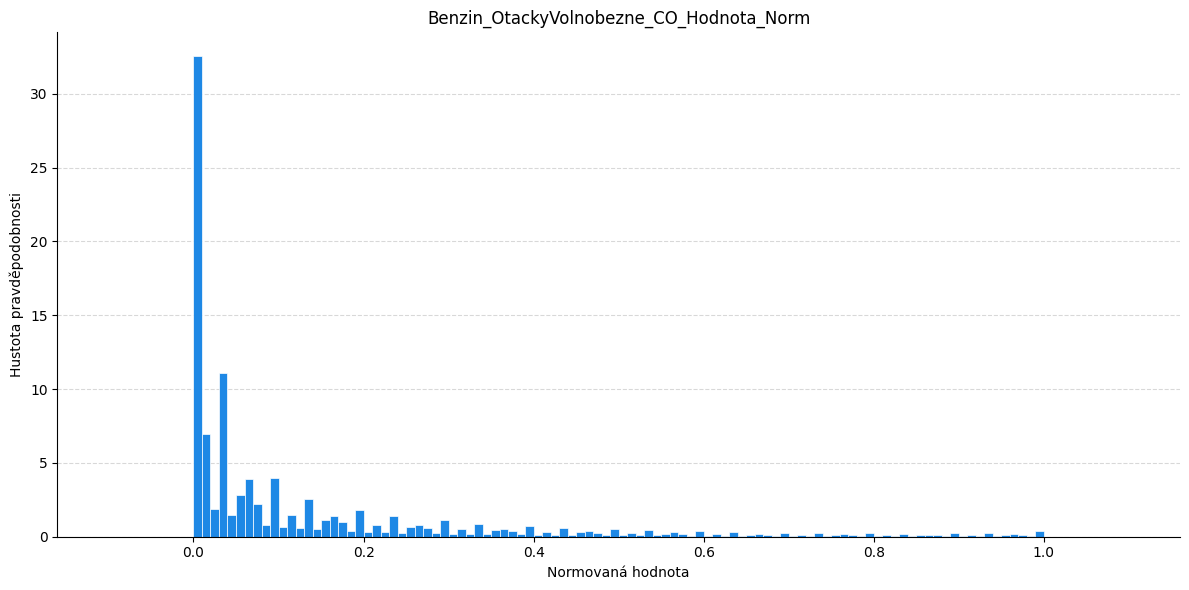

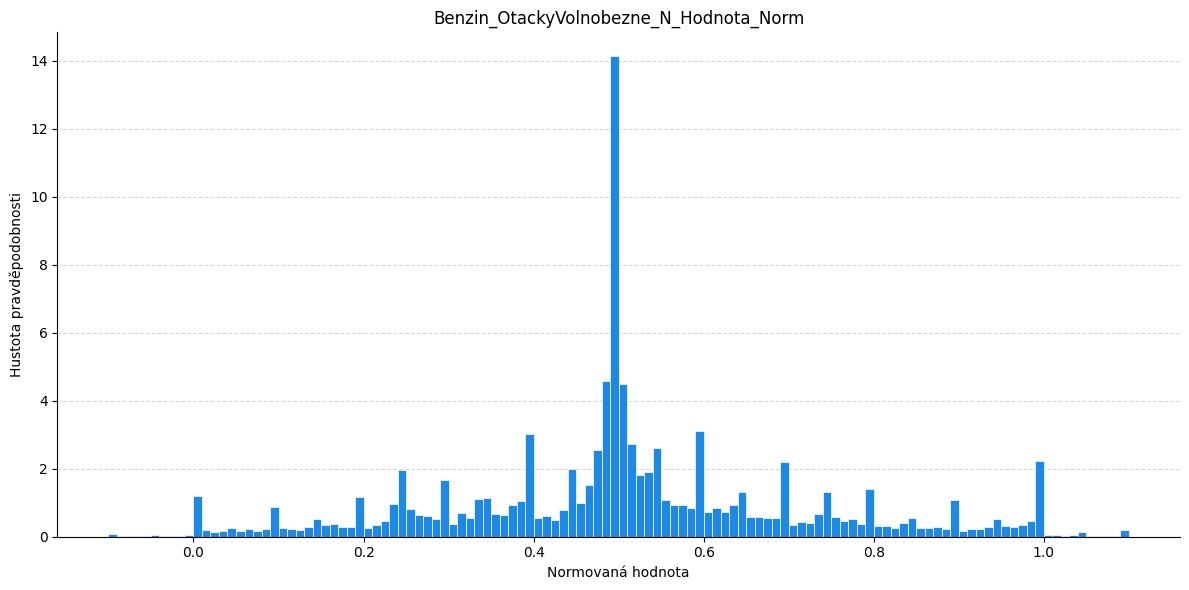

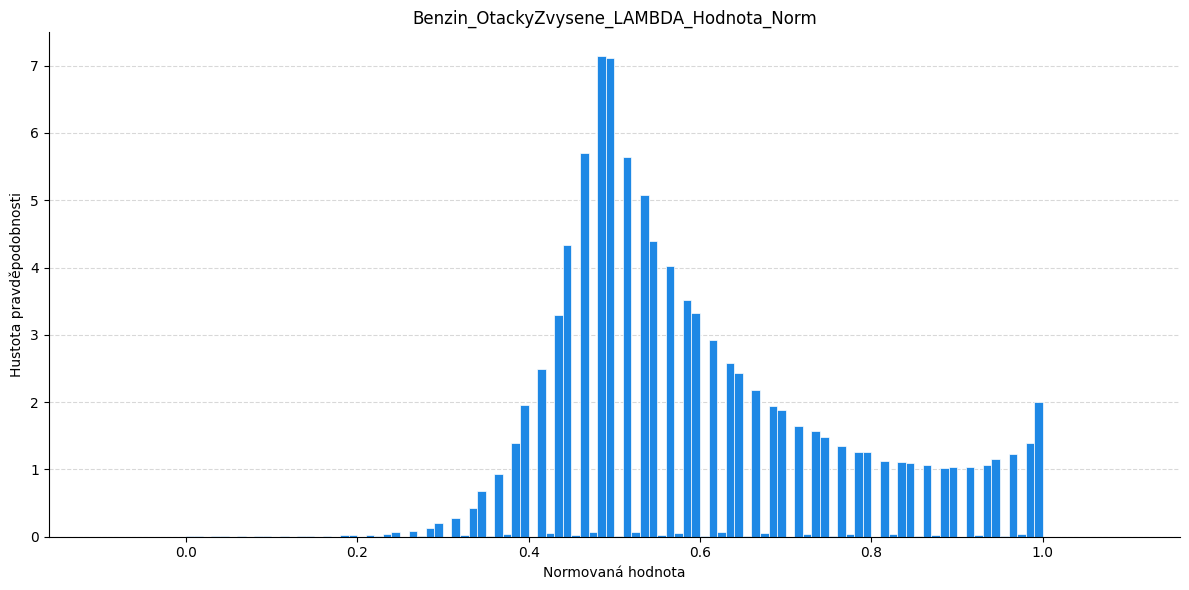

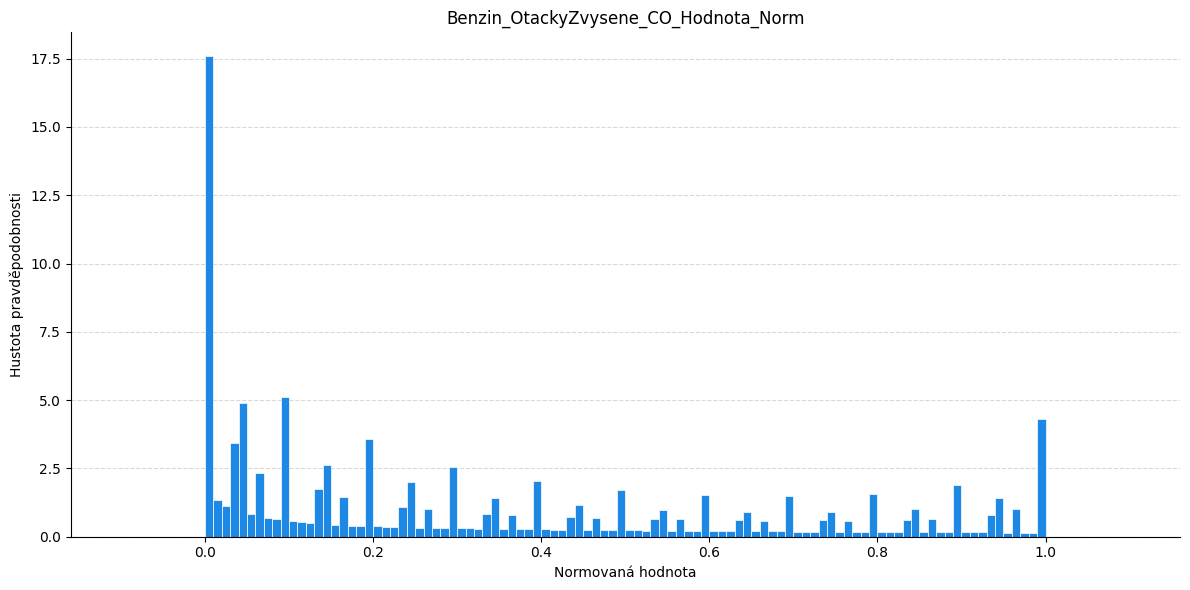

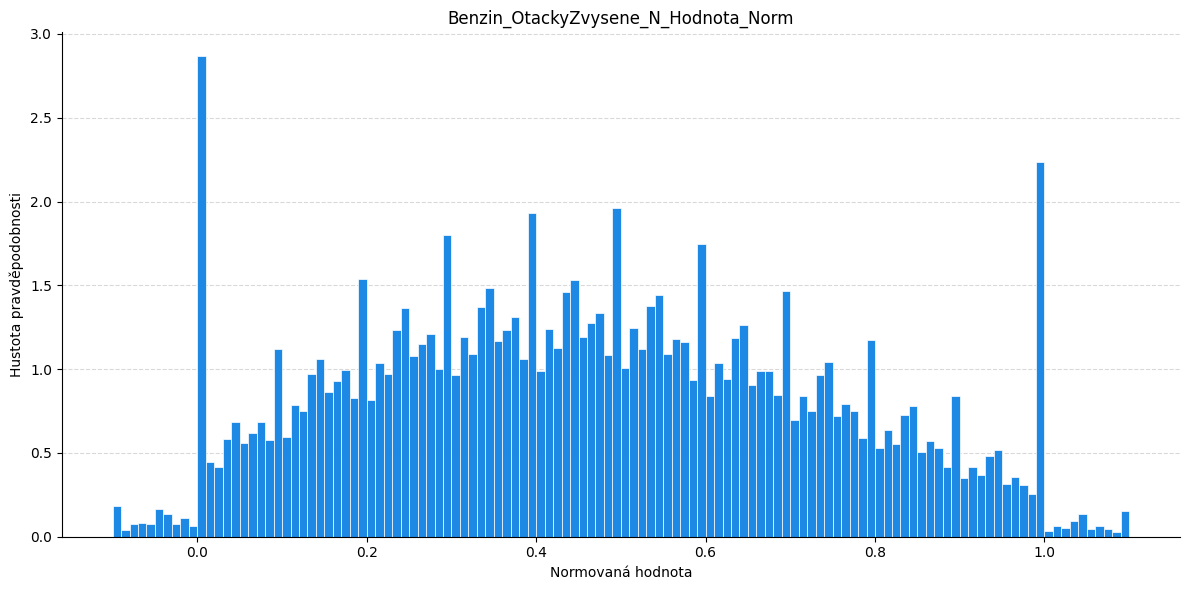

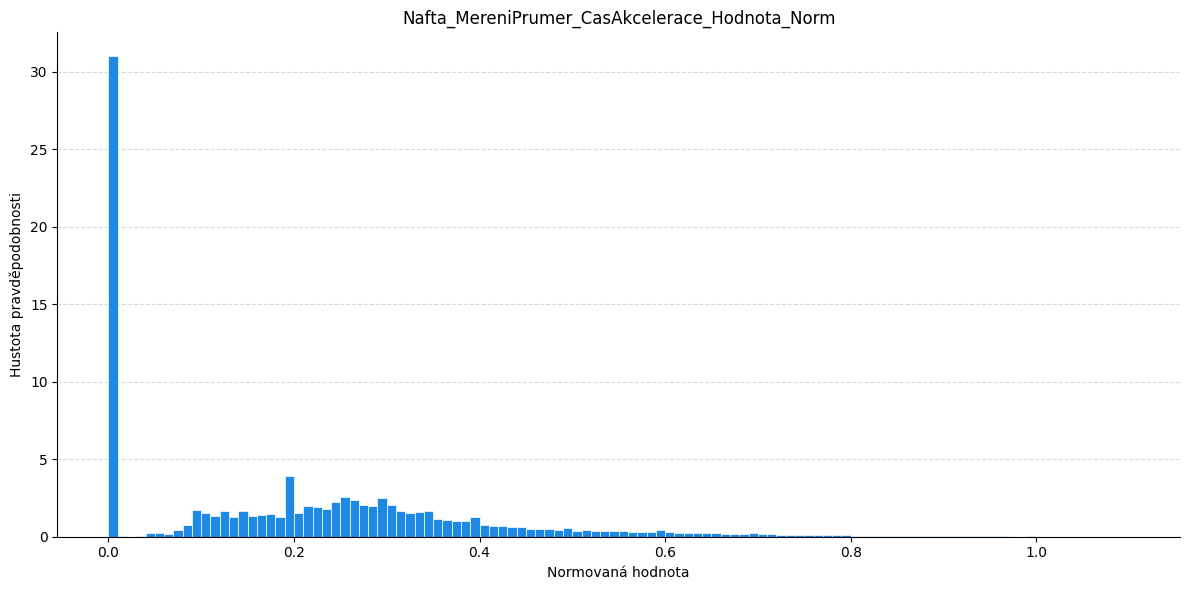

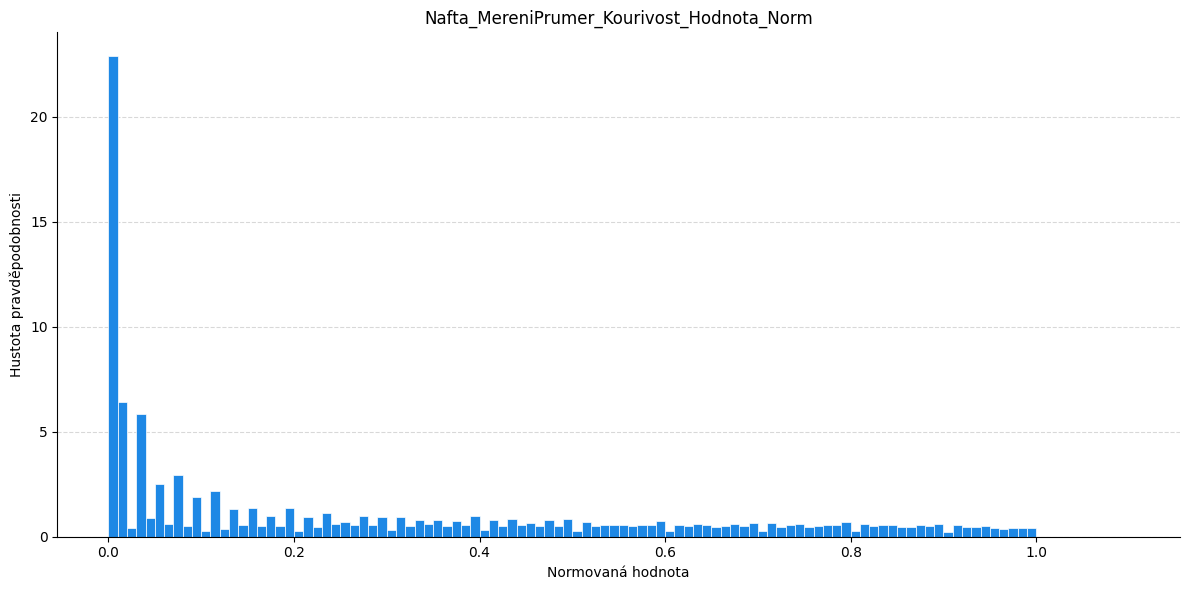

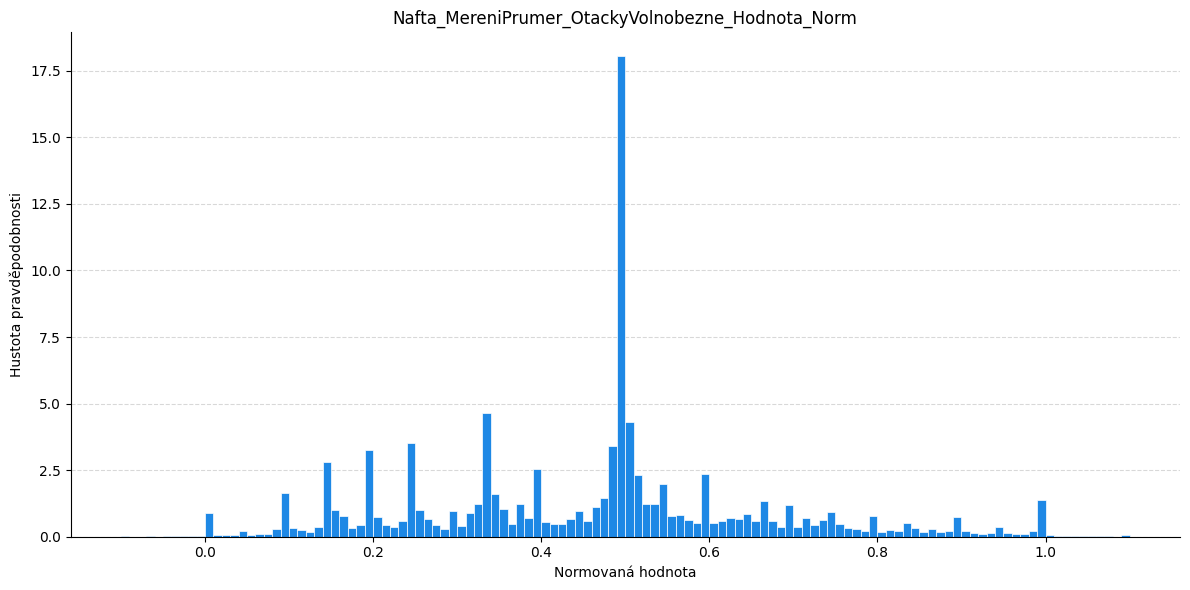

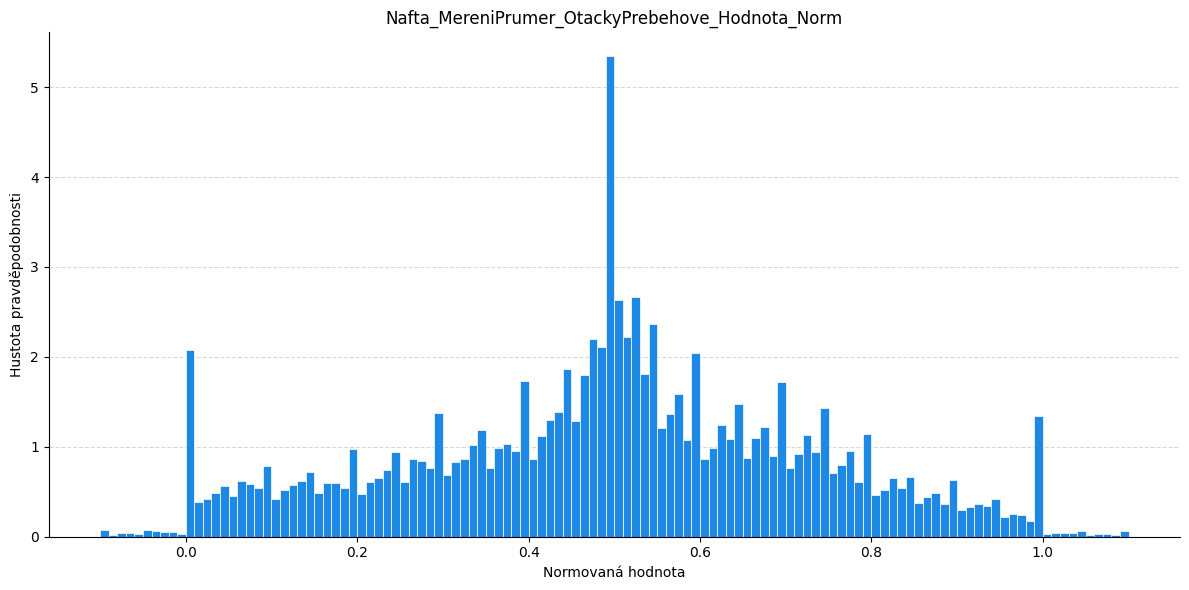

In [36]:
def plot_norms(df):
    for col in df.columns:
        distribution_density_plot(df.filter(pl.col(col).is_between(-0.1, 1.1)), col, col, 'Normovaná hodnota', 100, (0, 1.00001), save_path=f'kod/explorace/mereni_grafy/rozdeleni_{col}.svg')
plot_norms(df_benzin)
plot_norms(df_nafta)

# Vývoj počtu anomálních měření v čase
- Hodnoty mimo povoleny rozsah, kde prohlidka presto skoncila uspesne
- Mereni, ktera maji hodnoty u kraje intervalu v definovanych merenich, kde je na to relativne mala sance

In [37]:
def time_series_preaggregated(x, y, title, y_title, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(x, y, marker=',' if len(x) > 10 else 'o')

    ax.set_title(title)
    ax.set_xlabel("Rok")
    ax.set_ylabel(y_title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom=0.0, top=y.max() * 1.1)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.4f'))
    
    fig.autofmt_xdate()

    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, format="svg", bbox_inches="tight")
 
    plt.show()

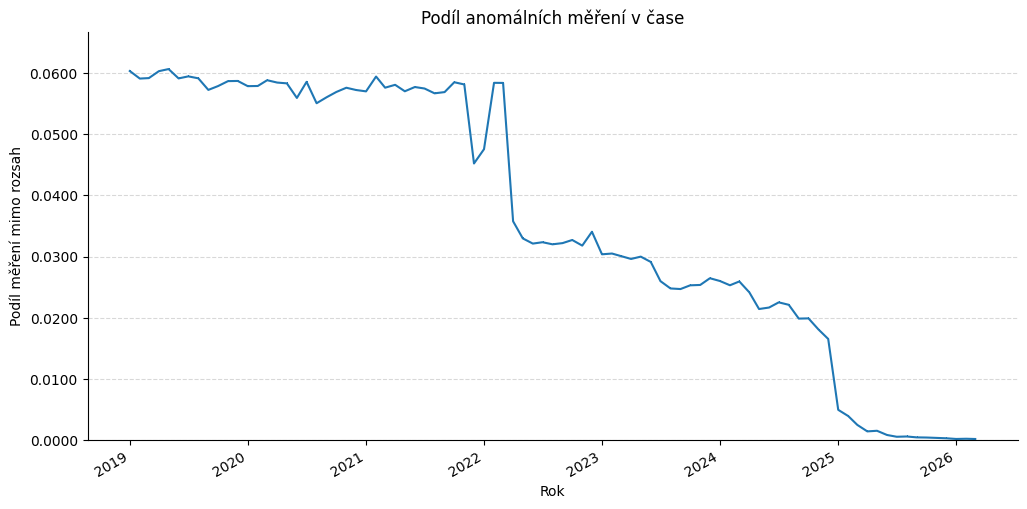

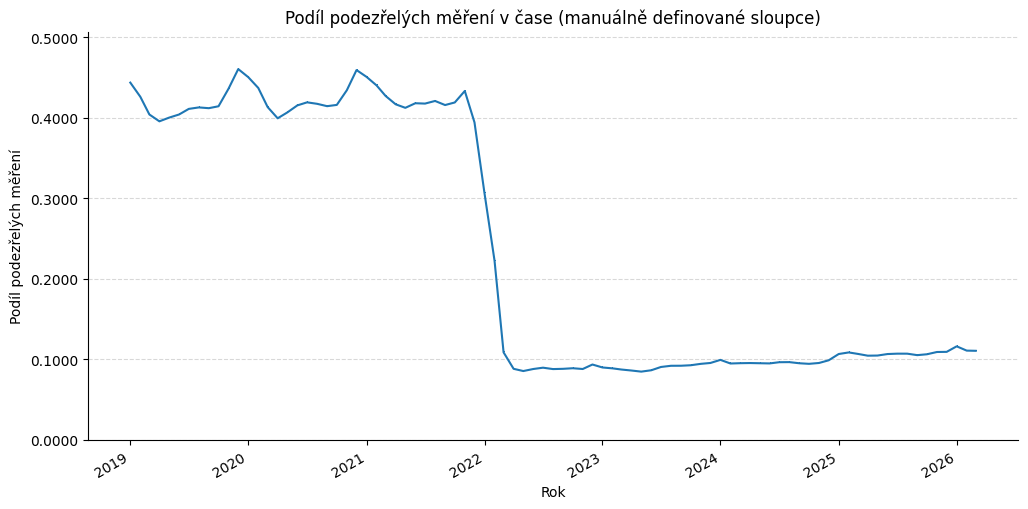

In [38]:
if PRINT:
    lf_time = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).select(['CisloProtokolu', 'Zahajeni'])
    
    df_base = (
        df_small.lazy()
        .join(lf_time, on='CisloProtokolu', how='left')
        .with_columns(pl.col('Zahajeni').cast(pl.Datetime).alias('ts'))
        .filter(pl.col('ts').is_not_null())
        .sort('ts')
    )

    # Anomální
    norm_cols = [c for c in df_small.columns if c.endswith('_Norm')]
    out_of_bounds_exprs = [(pl.col(c) < 0) | (pl.col(c) > 1) for c in norm_cols]
    
    df_anomalies_norm = (
        df_base
        .with_columns(pl.any_horizontal(out_of_bounds_exprs).fill_null(False).alias("Is_Anomalous"))
        .group_by_dynamic('ts', every='1mo')
        .agg((pl.col('Is_Anomalous').sum() / pl.len()).alias('Normalized'))
        .collect()
    )
    
    time_series_preaggregated(
        x=df_anomalies_norm['ts'], 
        y=df_anomalies_norm['Normalized'],
        title='Podíl anomálních měření v čase', 
        y_title='Podíl měření mimo rozsah', 
        save_path='kod/explorace/mereni_grafy/mereni_anomalie_cas.svg'
    )

    # Podezřelá
    epsilon = 0.01
    manual_cols = [
        'Benzin_OtackyVolnobezne_N_Hodnota_Norm', 
        'Benzin_OtackyZvysene_N_Hodnota_Norm', 
        'Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm', 
        'Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 
        'Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm'
    ]
    
    suspect_exprs = [
        pl.col(c).is_between(-epsilon, epsilon) | pl.col(c).is_between(1 - epsilon, 1 + epsilon) 
        for c in manual_cols
    ]
    
    df_suspect_norm = (
        df_base
        .with_columns(pl.any_horizontal(suspect_exprs).fill_null(False).alias("Is_Suspect"))
        .group_by_dynamic('ts', every='1mo')
        .agg((pl.col('Is_Suspect').sum() / pl.len()).alias('Normalized'))
        .collect()
    )
    
    time_series_preaggregated(
        x=df_suspect_norm['ts'], 
        y=df_suspect_norm['Normalized'],
        title='Podíl podezřelých měření v čase (manuálně definované sloupce)', 
        y_title='Podíl podezřelých měření', 
        save_path='kod/explorace/mereni_grafy/mereni_podezrela_cas.svg'
    )

# Finální příprava pro tvorbu modelu

## Sparovani pristich vysledku s merenimi

In [39]:
lf_full = pl.scan_parquet(r'kod\data\extracted\data_z_mericich_pristroju\parquet', schema=mereni_schema).pipe(cast_mereni)

lf_shifted_result = (
    lf_full
    .select(["CisloProtokolu", "Vozidlo_Vin", "Zahajeni", "Vysledek_Vyhovuje"])
    .sort(["Vozidlo_Vin", "Zahajeni"])
    .with_columns(
        Vysledek_Pristi_Raw=pl.col("Vysledek_Vyhovuje").shift(-1).over("Vozidlo_Vin"),
        Pristi_Zaznam_Existuje=pl.col("CisloProtokolu").shift(-1).over("Vozidlo_Vin").is_not_null()
    )
    .with_columns(
        Vysledek_Pristi=pl.when(pl.col("Pristi_Zaznam_Existuje"))
        .then(pl.col("Vysledek_Pristi_Raw").fill_null(False))
        .otherwise(None)
    )
    .unique(subset=['CisloProtokolu'])
    .select(["CisloProtokolu", "Vysledek_Pristi"])
)

df_small = (df_small.lazy().join(lf_shifted_result, on="CisloProtokolu", how="left").collect())

## Odstraneni mereni, ktera nemaji znamy pristi vysledek

In [40]:
if PRINT: display(df_small['Vysledek_Pristi'].value_counts())
df_small = df_small.filter(pl.col('Vysledek_Pristi').is_not_null())

Vysledek_Pristi,count
bool,u32
false,327399
true,11653990
null,6873430


# Aplikovani stejnych filtru na df jako na df_model

In [41]:
df = df.join(df_small.select(['CisloProtokolu', 'Vysledek_Pristi']), on='CisloProtokolu', how='inner')
if PRINT:
    print(f'Delka df_model: {df_small.height}')
    print(f'Delka df:       {df.height}')

Delka df_model: 11981389
Delka df:       11981389


## Uprava nekterych sloupcu df do formatu vhodneho pro analyzu

In [42]:
# Redukce seznamu na jejich pocet
df = df.with_columns(pl.col(pl.List).list.len().fill_null(0))
# Emisni system na pritomnost OBD
df = df.with_columns(pl.col('EmisniSystem') == 'Rizeny_Obd').rename({'EmisniSystem': 'OBD_Pritomno'})

# Ulozeni dat pro trenovani modelu

In [43]:
df_small.write_parquet(r"kod\data\processed\mereni_model.parquet")
df.write_parquet(r"kod\data\processed\mereni_model_raw.parquet")

In [44]:
if PRINT:
    describe(df_small)
    describe(df)

CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Benzin_PocetVyusteni,Nafta_PocetVyusteni,Benzin_OtackyVolnobezne_CO_Hodnota_Norm,Benzin_OtackyVolnobezne_N_Hodnota_Norm,Benzin_OtackyZvysene_LAMBDA_Hodnota_Norm,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
str,bool,bool,i8,i8,bool,u32,u32,bool,str,i8,i32,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,u32,u32,bool
"""CZ-480534-19-10-0443""",true,true,1,2,true,0,4,true,"""ISO 15765""",2,0,0,1,null,null,null,null,null,0.0,0.0,0.25,0.575,"""AVL DiTEST GmbHAVL DiSmoke 480""",4,11,true


(11981389, 27)


,CisloProtokolu,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,...,Benzin_OtackyZvysene_CO_Hodnota_Norm,Benzin_OtackyZvysene_N_Hodnota_Norm,Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm,Nafta_MereniPrumer_Kourivost_Hodnota_Norm,Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm,Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm,MericiPristroj_Info,Pocet_Podporovano,Pocet_Otestovano,Vysledek_Pristi
0,CZ-480534-19-10-0443,True,True,1,2.0,True,0,4,True,ISO 15765,...,NaN,NaN,0.000,0.000000,0.250000,0.575000,AVL DiTEST GmbHAVL DiSmoke 480,4,11,True
1,CZ-410533-21-06-0008,True,True,1,2.0,True,0,3,True,WWH-OBD (ISO 27145),...,NaN,NaN,0.000,0.000000,0.070000,0.400000,BoschBEA070,8,11,True
2,CZ-580306-23-10-0102,True,False,1,2.0,True,0,3,True,ISO 14230,...,1.000000,1.000000,NaN,NaN,NaN,NaN,ATAL s.r.o.AT505,6,8,True
3,CZ-480828-22-07-0209,True,True,1,2.0,True,0,3,True,SAE J1850 PWM,...,0.366667,0.992000,NaN,NaN,NaN,NaN,MAHLEAGS-200,6,11,True
4,CZ-421133-22-11-0231,True,True,1,2.0,True,0,3,True,ISO 15765 (CAN),...,NaN,NaN,0.064,0.000000,0.505000,0.680000,ACTIA CZ s.r.o.AT605,6,11,True
5,CZ-410945-21-06-0608,True,False,1,2.0,True,0,3,True,CAN (ISO 15765-4),...,NaN,NaN,0.000,0.000000,0.750000,0.540000,BoschBEA070,8,8,True
6,CZ-580518-21-06-0445,True,False,2,2.0,False,0,1,True,ISO 15765,...,0.050000,0.219000,NaN,NaN,NaN,NaN,ActiaCZAT505,6,5,True
7,CZ-580601-19-09-0548,True,None,1,2.0,None,0,2,False,None,...,NaN,NaN,0.000,0.152778,0.550000,0.400000,AVL DiTEST GmbHAVL DiSmoke 480,0,0,True
8,CZ-510808-20-10-0076,True,False,1,2.0,True,0,3,True,ISO 15765,...,1.000000,-0.125000,NaN,NaN,NaN,NaN,ActiaCZAT505,7,10,True
9,CZ-540404-22-07-0141,True,False,1,2.0,False,0,1,True,ISO 15765,...,NaN,NaN,0.440,0.134615,0.495000,0.240000,BoschBEA 950,6,0,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-450915-22-01-0341,1 / 11 981 389,0 / 11 981 389,String
1,Vysledek_VisualniKontrola,True,11 980 544 / 11 981 389,0 / 11 981 389,Boolean
2,Vysledek_Readiness,True,8 212 830 / 11 981 389,1 786 455 / 11 981 389,Boolean
3,Vysledek_RidiciJednotkaStav,1,11 450 918 / 11 981 389,403 502 / 11 981 389,Int8
4,Vysledek_Mil,2,11 426 921 / 11 981 389,547 178 / 11 981 389,Int8
5,Obd_Readiness_Vysledek,True,9 473 646 / 11 981 389,1 885 461 / 11 981 389,Boolean
6,Zavady,0,11 971 134 / 11 981 389,0 / 11 981 389,UInt32
7,Poznamky,2,3 960 550 / 11 981 389,0 / 11 981 389,UInt32
8,OBD_Pritomno,True,10 095 928 / 11 981 389,0 / 11 981 389,Boolean
9,Obd_KomunikacniProtokol,ISO 15765,4 012 045 / 11 981 389,1 885 461 / 11 981 389,String


CisloProtokolu,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,Vysledek_Vyhovuje,Obd_Readiness_Vysledek,Zavady,Poznamky,OBD_Pritomno,Obd_KomunikacniProtokol,Obd_KontrolaMil,Obd_PocetDtc,Obd_VypisDtc,Obd_VzdalenostDtc,Obd_CasDtc,Obd_Readiness_Zazeh_AC_Otestovano,Obd_Readiness_Zazeh_AC_Podporovano,Obd_Readiness_Zazeh_CAT-FUNC_Otestovano,Obd_Readiness_Zazeh_CAT-FUNC_Podporovano,Obd_Readiness_Zazeh_COMP_Otestovano,Obd_Readiness_Zazeh_COMP_Podporovano,Obd_Readiness_Zazeh_EGR-VVT_Otestovano,Obd_Readiness_Zazeh_EGR-VVT_Podporovano,Obd_Readiness_Zazeh_EVAP_Otestovano,Obd_Readiness_Zazeh_EVAP_Podporovano,Obd_Readiness_Zazeh_FUEL_Otestovano,Obd_Readiness_Zazeh_FUEL_Podporovano,Obd_Readiness_Zazeh_HCAT_Otestovano,Obd_Readiness_Zazeh_HCAT_Podporovano,Obd_Readiness_Zazeh_MISF_Otestovano,Obd_Readiness_Zazeh_MISF_Podporovano,Obd_Readiness_Zazeh_O2S-FUNC_Otestovano,Obd_Readiness_Zazeh_O2S-FUNC_Podporovano,Obd_Readiness_Zazeh_O2S-HEAT_Otestovano,Obd_Readiness_Zazeh_O2S-HEAT_Podporovano,Obd_Readiness_Zazeh_SAS_Otestovano,Obd_Readiness_Zazeh_SAS_Podporovano,Obd_Readiness_Vznet_AC_Otestovano,Obd_Readiness_Vznet_AC_Podporovano,Obd_Readiness_Vznet_BOOST_Otestovano,Obd_Readiness_Vznet_BOOST_Podporovano,Obd_Readiness_Vznet_COMP_Otestovano,Obd_Readiness_Vznet_COMP_Podporovano,Obd_Readiness_Vznet_DPF_Otestovano,Obd_Readiness_Vznet_DPF_Podporovano,Obd_Readiness_Vznet_EGR-VVT_Otestovano,Obd_Readiness_Vznet_EGR-VVT_Podporovano,Obd_Readiness_Vznet_EGS_Otestovano,Obd_Readiness_Vznet_EGS_Podporovano,Obd_Readiness_Vznet_FUEL_Otestovano,Obd_Readiness_Vznet_FUEL_Podporovano,Obd_Readiness_Vznet_MISF_Otestovano,Obd_Readiness_Vznet_MISF_Podporovano,Obd_Readiness_Vznet_NMHC_Otestovano,Obd_Readiness_Vznet_NMHC_Podporovano,Obd_Readiness_Vznet_NOX_Otestovano,Obd_Readiness_Vznet_NOX_Podporovano,Obd_Readiness_Vznet_RESERVE_Otestovano,Obd_Readiness_Vznet_RESERVE_Podporovano,Benzin_PocetVyusteni,Benzin_OtackyVolnobezne_CO2_Hodnota,Benzin_OtackyVolnobezne_CO2_Vysledek,Benzin_OtackyVolnobezne_COCOOR_Hodnota,Benzin_OtackyVolnobezne_COCOOR_Vysledek,Benzin_OtackyVolnobezne_CO_Hodnota,Benzin_OtackyVolnobezne_CO_Max_Hodnota,Benzin_OtackyVolnobezne_CO_Max_RucniZadani,Benzin_OtackyVolnobezne_CO_Vysledek,Benzin_OtackyVolnobezne_HC_Hodnota,Benzin_OtackyVolnobezne_HC_Max_Hodnota,Benzin_OtackyVolnobezne_HC_Max_RucniZadani,Benzin_OtackyVolnobezne_HC_Vysledek,Benzin_OtackyVolnobezne_LAMBDA_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Max_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Max_RucniZadani,Benzin_OtackyVolnobezne_LAMBDA_Min_Hodnota,Benzin_OtackyVolnobezne_LAMBDA_Min_RucniZadani,Benzin_OtackyVolnobezne_LAMBDA_Vysledek,Benzin_OtackyVolnobezne_NOX_Hodnota,Benzin_OtackyVolnobezne_NOX_Vysledek,Benzin_OtackyVolnobezne_N_Hodnota,Benzin_OtackyVolnobezne_N_Max_Hodnota,Benzin_OtackyVolnobezne_N_Max_RucniZadani,Benzin_OtackyVolnobezne_N_Min_Hodnota,Benzin_OtackyVolnobezne_N_Min_RucniZadani,Benzin_OtackyVolnobezne_N_Vysledek,Benzin_OtackyVolnobezne_O2_Hodnota,Benzin_OtackyVolnobezne_O2_Vysledek,Benzin_OtackyVolnobezne_TPS_Hodnota,Benzin_OtackyVolnobezne_TPS_Vysledek,Benzin_OtackyZvysene_CO2_Hodnota,Benzin_OtackyZvysene_CO2_Vysledek,Benzin_OtackyZvysene_COCOOR_Hodnota,Benzin_OtackyZvysene_COCOOR_Vysledek,Benzin_OtackyZvysene_CO_Hodnota,Benzin_OtackyZvysene_CO_Max_Hodnota,Benzin_OtackyZvysene_CO_Max_RucniZadani,Benzin_OtackyZvysene_CO_Vysledek,Benzin_OtackyZvysene_HC_Hodnota,Benzin_OtackyZvysene_HC_Max_Hodnota,Benzin_OtackyZvysene_HC_Max_RucniZadani,Benzin_OtackyZvysene_HC_Vysledek,Benzin_OtackyZvysene_LAMBDA_Hodnota,Benzin_OtackyZvysene_LAMBDA_Max_Hodnota,Benzin_OtackyZvysene_LAMBDA_Max_RucniZadani,Benzin_OtackyZvysene_LAMBDA_Min_Hodnota,Benzin_OtackyZvysene_LAMBDA_Min_RucniZadani,Benzin_OtackyZvysene_LAMBDA_Vysledek,Benzin_OtackyZvysene_NOX_Hodnota,Benzin_OtackyZvysene_NOX_Vysledek,Benzin_OtackyZvysene_N_Hodnota,Benzin_OtackyZvysene_N_Max_Hodnota,Benzin_Ot

(11981389, 202)


,CisloProtokolu,MericiPristroj_Vyrobce,MericiPristroj_Typ,MericiPristroj_Verze,MericiPristroj_OBD,MericiPristroj_VerzeSoftware,Vysledek_VisualniKontrola,Vysledek_Readiness,Vysledek_RidiciJednotkaStav,Vysledek_Mil,...,Nafta_Mereni3_Kourivost_Vysledek,Nafta_Mereni3_OtackyPrebehove_Hodnota,Nafta_Mereni3_OtackyPrebehove_Vysledek,Nafta_Mereni3_OtackyVolnobezne_Hodnota,Nafta_Mereni3_OtackyVolnobezne_Vysledek,Nafta_Mereni3_TPS_Hodnota,Nafta_Mereni3_TPS_Vysledek,Nafta_Mereni3_Teplota_Hodnota,Nafta_Mereni3_Teplota_Vysledek,Vysledek_Pristi
0,CZ-480534-19-10-0443,AVL DiTEST GmbH,AVL DiSmoke 480,V2.4 08/2008,AVL OBD 1000,V2.4.2 02/2017,True,True,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,CZ-410533-21-06-0008,Bosch,BEA070,BEA070 V1.19 CFFE0424,KTS515,V1.21,True,True,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,CZ-580306-23-10-0102,ATAL s.r.o.,AT505,-,R+OBD,3.06.3,True,False,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,CZ-480828-22-07-0209,MAHLE,AGS-200,-,ano,2021.0.1,True,True,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4,CZ-421133-22-11-0231,ACTIA CZ s.r.o.,AT605,-,R+OBD,3.6,True,True,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
5,CZ-410945-21-06-0608,Bosch,BEA070,BEA070 V1.19 CFFE0424,KTS540,V1.21,True,False,1,2.0,...,1.0,5008.0,1.0,775.0,1.0,0.0,2.0,0.0,1.0,True
6,CZ-580518-21-06-0445,ActiaCZ,AT505,sw: 2.04.3,ano,sw: 2.04.3,True,False,2,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
7,CZ-580601-19-09-0548,AVL DiTEST GmbH,AVL DiSmoke 480,V2.4 08/2008,None,V2.4.2 02/2017,True,None,1,2.0,...,1.0,2710.0,1.0,600.0,1.0,0.0,2.0,85.0,1.0,True
8,CZ-510808-20-10-0076,ActiaCZ,AT505,-,R+OBD,2.08.3,True,False,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
9,CZ-540404-22-07-0141,Bosch,BEA 950,/ BEA070 V1.19 CFFE0424,KTS560,1.0,True,False,1,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


,column,majority_class,majority_cnt,null,dtype
0,CisloProtokolu,CZ-420913-23-08-0011,1 / 11 981 389,0 / 11 981 389,String
1,MericiPristroj_Vyrobce,Bosch,3 746 817 / 11 981 389,0 / 11 981 389,String
2,MericiPristroj_Typ,AT605,1 602 768 / 11 981 389,0 / 11 981 389,String
3,MericiPristroj_Verze,-,4 046 999 / 11 981 389,547 200 / 11 981 389,String
4,MericiPristroj_OBD,R+OBD,2 429 255 / 11 981 389,1 298 385 / 11 981 389,String
...,...,...,...,...,...
197,Nafta_Mereni3_TPS_Hodnota,0.0,1 142 321 / 11 981 389,10 581 942 / 11 981 389,Float32
198,Nafta_Mereni3_TPS_Vysledek,2,1 391 867 / 11 981 389,10 581 942 / 11 981 389,Int8
199,Nafta_Mereni3_Teplota_Hodnota,0.0,436 824 / 11 981 389,10 366 230 / 11 981 389,Float32
200,Nafta_Mereni3_Teplota_Vysledek,1,1 344 073 / 11 981 389,10 366 230 / 11 981 389,Int8
